Analisis del Titanic
1.Descripcion del analisis
Este analisis explora los factores que influyeron en la supervivencia de los pasajeros del titanic, usando un dataset de 891 registros.

2.Carga de Datos

In [1]:
import pandas as pd
#Cargamos un dataset directo desde internet
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

3.Exploracion inicial.

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
(df.isnull().sum()/len(df)*100).round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

4. Limpieza de Datos

In [6]:
##Rellenar con la mediana para numeros como Age
df["Age"] = df["Age"].fillna(df["Age"].median())
##Rellenar con el valor mas frecuente para texto como Embarked
df["Embarked"] = df ["Embarked"].fillna(df["Embarked"].mode()[0])
##Eliminar columna completa cuando hay demasiados nulos
df = df.drop(columns=["Cabin"])
#Extra eliminar columnas que no sirven para analizar 
#PassengerId , Name y Ticket no aportan nada al analisis
df = df.drop(columns=["PassengerId","Name","Ticket"])

In [7]:
##Verificamos que quede limpio
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Se eliminaron las columnas Cabin (77% nulos), PassengerId, Name y Ticket
por no aportar valor al análisis. La columna Age se rellenó con la mediana (35).

5. Preguntas de negocio

In [14]:
# 1.¿Cual fue la tasa de supervivencia general?
df["Survived"].mean().round(2)


np.float64(0.38)

Hallazgo 1 : La tasa de supervivencia general fue del 38% es decir que por cada 100 solo sobrevivian 38 personas 

In [15]:
# 2.¿Sobrevivieron mas hombres o mujeres?
df.groupby("Sex")["Survived"].mean().round(2)


Sex
female    0.74
male      0.19
Name: Survived, dtype: float64

Hallazgo 2 : Las mujeres fueron el triple de sobrevivientes a diferencia de los hombres

In [16]:
# 3.¿Qué clase tuvo más sobrevivientes?
df.groupby("Pclass")["Survived"].mean().round(2)


Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

Hallazgo 3 : La primera clase fue la que tuvo mas sobrevivientes se infiere que las personas de tercera clase casi no tuvo sobrevivientes

In [17]:
# 4.¿Los pasajeros más jovenes sobrevivieron más?
df.groupby(pd.cut(df["Age"], bins=[0,18,40,60,100],
                 labels=["Niño","Adulto Joven","Adulto","Mayor"]))["Survived"].mean().round(2)


C:\Users\tona_\AppData\Local\Temp\ipykernel_31748\1688899977.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["Age"], bins=[0,18,40,60,100],


Age
Niño            0.50
Adulto Joven    0.36
Adulto          0.39
Mayor           0.23
Name: Survived, dtype: float64

Hallazgo 4 : Los niños de 0 a 18 años tuvieron la mayor tasa de supervivencia con un 50% , sugiriendo que se priorizo evacuar a los menores

In [18]:
# 5.¿Los que pagaron más tuvieron más probabilidad de sobrevivir?
df.groupby("Survived")["Fare"].mean().round(2)

Survived
0    22.12
1    48.40
Name: Fare, dtype: float64

Hallazgo 5: Los que pagaron una tarifa mas alta fueron los que tuvieron mas probabilidad de sobrevivir.

6. Visualizaciones

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

C:\Users\tona_\AppData\Local\Temp\ipykernel_31748\111217918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Sex", y="Survived", palette="Set2")


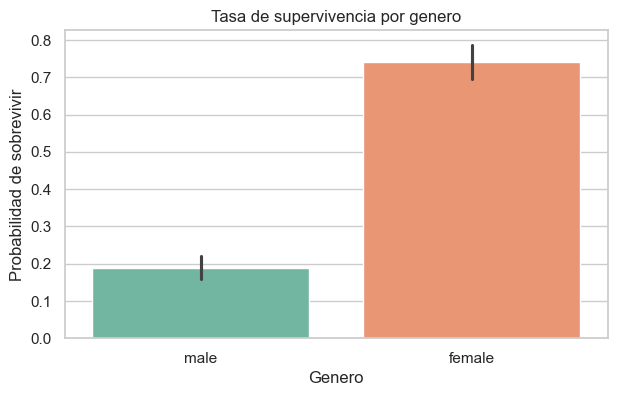

In [20]:
plt.figure(figsize=(7,4))
sns.barplot(data=df,x="Sex", y="Survived", palette="Set2")
plt.title("Tasa de supervivencia por genero")
plt.ylabel("Probabilidad de sobrevivir")
plt.xlabel("Genero")
plt.show()

C:\Users\tona_\AppData\Local\Temp\ipykernel_31748\637330146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")


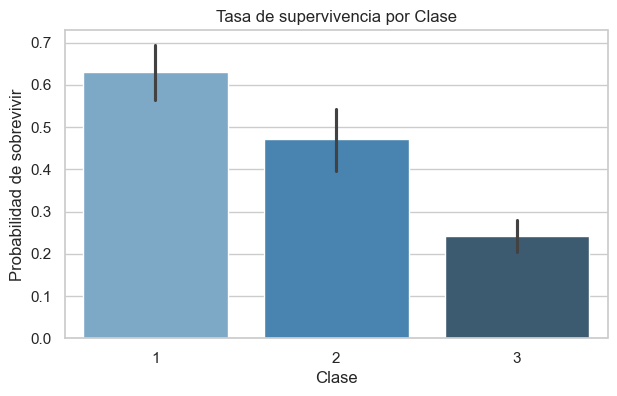

In [22]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")
plt.title("Tasa de supervivencia por Clase")
plt.ylabel("Probabilidad de sobrevivir")
plt.xlabel("Clase")
plt.show()

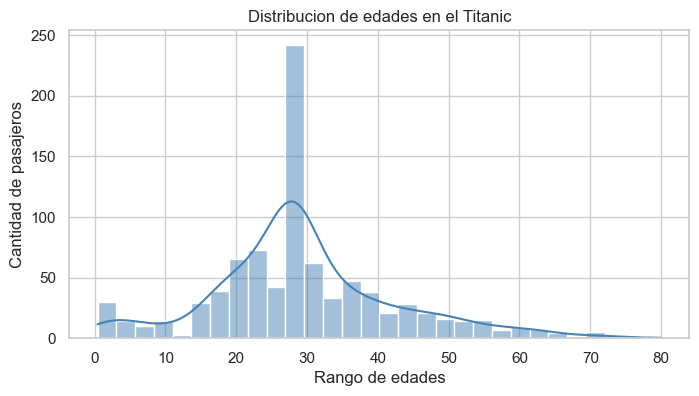

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Age", bins=30 , kde=True, color="steelblue")
plt.title("Distribucion de edades en el Titanic")
plt.xlabel("Rango de edades")
plt.ylabel("Cantidad de pasajeros")
plt.show()

7.Conclusiones
- Solo el 38% de los pasajeros sobrevivió
- Las mujeres sobrevivieron 3 veces más que los hombres (74% vs 19%)
- La primera clase tuvo el doble de supervivencia que la tercera
- Los pasajeros que sobrevivieron pagaron en promedio el doble de tarifa